# Results RSA: Within-Group-Analysis
## Model Comparison Segmental vs. Random Model, Segmental vs. Simple Model at 80 Hz



**Author:** Monika Doerig, 8 Oct 2025  

[<img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" width="20"> MoniDoerig](https://github.com/MoniDoerig)

[<img src="https://info.orcid.org/wp-content/uploads/2019/11/orcid_16x16.png" width="20"> 0009-0008-3617-2185](https://orcid.org/0009-0008-3617-2185)


In [1]:
%%capture
!pip install nibabel nilearn siibra 

In [2]:
import os
from os.path import join as opj
import nibabel as nib
import numpy as np

from nilearn.plotting import plot_stat_map, plot_glass_brain, plot_roi, show
from nibabel.processing import resample_from_to
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import siibra
import warnings
import logging

# Suppress nilearn FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning, module='nilearn')

# Reduce siibra logging level
logging.getLogger('siibra').setLevel(logging.WARNING)

[siibra:INFO] Version: 1.0.1-alpha.11
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.


### Import data

In [3]:
base_path_hc = '/mnt/neurodesktop-storage/Data/tempRSA/RSA/Model_Comparison_HCs/output'

N41HC_Seg80minusRan80_path = opj(base_path_hc, '1sampTtest_perm10k_N41_Seg80minusRan80_tfce_corrp_tstat1.nii.gz')
N41HC_Seg80minusSim80_path = opj(base_path_hc, '1sampTtest_perm10k_N41_Seg80minusSim80_tfce_corrp_tstat1.nii.gz')
N41HC_Sim80minusRan80_path = opj(base_path_hc, '1sampTtest_perm10k_N41_Sim80minusRan80_tfce_corrp_tstat1.nii.gz')

In [4]:
base_path_pat = '/mnt/neurodesktop-storage/Data/tempRSA/RSA/Model_Comparison_PAT/output'

N45_Seg80minusRan80_path = (opj(base_path_pat, '1sampTtest_perm10k_N45_Seg80minusRan80_tfce_corrp_tstat1.nii.gz'))
N45_Seg80minusSim80_path = (opj(base_path_pat, '1sampTtest_perm10k_N45_Seg80minusSim80_tfce_corrp_tstat1.nii.gz'))
N45_Sim80minusRan80_path = (opj(base_path_pat, '1sampTtest_perm10k_N45_Sim80minusRan80_tfce_corrp_tstat1.nii.gz'))

### Get brain regions from siibra

[siibra:WARNING] Non unique indices encountered in Waxholm Space atlas of the Sprague Dawley rat brain delineations v1.01: {<MapIndex(volume=0, label=2, fragment=None)>}
[siibra:WARNING] Map registry contains multiple classes: Map, SparseMap


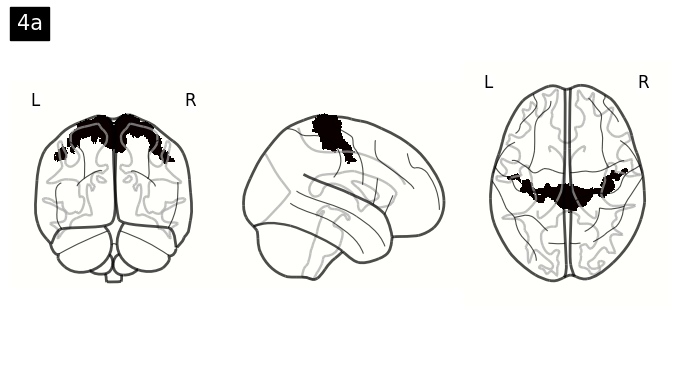

In [5]:
pc4a = siibra.get_region(parcellation='julich 3.0.3', region='4a')
pc4a_mask = pc4a.get_regional_mask(space="mni152", maptype="labelled")

pc4p = siibra.get_region(parcellation='julich 3.0.3', region='4p')
pc4p_mask = pc4p.get_regional_mask(space="mni152", maptype="labelled")

pc3a = siibra.get_region(parcellation='julich 3.0.3', region='3a')
pc3a_mask = pc3a.get_regional_mask(space="mni152", maptype="labelled")

pc3b = siibra.get_region(parcellation='julich 3.0.3', region='3b')
pc3b_mask = pc3b.get_regional_mask(space="mni152", maptype="labelled")

pc5l = siibra.get_region(parcellation='julich 3.0.3', region='5l')
pc5l_mask = pc5l.get_regional_mask(space="mni152", maptype="labelled")

pc5m = siibra.get_region(parcellation='julich 3.0.3', region='5m')
pc5m_mask = pc5m.get_regional_mask(space="mni152", maptype="labelled")

pc5ci = siibra.get_region(parcellation='julich 3.0.3', region='5Ci')
pc5ci_mask = pc5ci.get_regional_mask(space="mni152", maptype="labelled")

pc2 = siibra.get_region(parcellation='julich 3.0.3', region='2 (PostCS')
pc2_mask = pc2.get_regional_mask(space="mni152", maptype="labelled")

pc1 = siibra.get_region(parcellation='julich 3.0.3', region='1 (PostCG)')
pc1_mask = pc1.get_regional_mask(space="mni152", maptype="labelled")

pc6d1 = siibra.get_region(parcellation='julich 3.0.3', region='6d1')
pc6d1_mask = pc6d1.get_regional_mask(space="mni152", maptype="labelled")

pc7a = siibra.get_region(parcellation='julich 3.0.3', region='7a')
pc7a_mask = pc7a.get_regional_mask(space="mni152", maptype="labelled")

pc7pc = siibra.get_region(parcellation='julich 3.0.3', region='7pc')
pc7pc_mask = pc7pc.get_regional_mask(space="mni152", maptype="labelled")

display_4a = plot_glass_brain(pc4a_mask.fetch(), title="4a", threshold=None)

In [6]:
affine = nib.load(N41HC_Seg80minusRan80_path).affine
shape = nib.load(N41HC_Seg80minusRan80_path).shape

mask3a_resampled = resample_from_to(pc3a_mask.fetch(), (shape[:3], affine))
mask3b_resampled = resample_from_to(pc3b_mask.fetch(), (shape[:3], affine))
mask4a_resampled = resample_from_to(pc4a_mask.fetch(), (shape[:3], affine))
mask4p_resampled = resample_from_to(pc4p_mask.fetch(), (shape[:3], affine))
mask5l_resampled = resample_from_to(pc5l_mask.fetch(), (shape[:3], affine))
mask5m_resampled = resample_from_to(pc5m_mask.fetch(), (shape[:3], affine))
mask5ci_resampled = resample_from_to(pc5ci_mask.fetch(), (shape[:3], affine))
mask1_resampled = resample_from_to(pc1_mask.fetch(), (shape[:3], affine))
mask2_resampled = resample_from_to(pc2_mask.fetch(), (shape[:3], affine))
mask6d1_resampled = resample_from_to(pc6d1_mask.fetch(), (shape[:3], affine))
mask7a_resampled = resample_from_to(pc7a_mask.fetch(), (shape[:3], affine))
mask7pc_resampled = resample_from_to(pc7pc_mask.fetch(), (shape[:3], affine))

### Plot Brodmann Areas

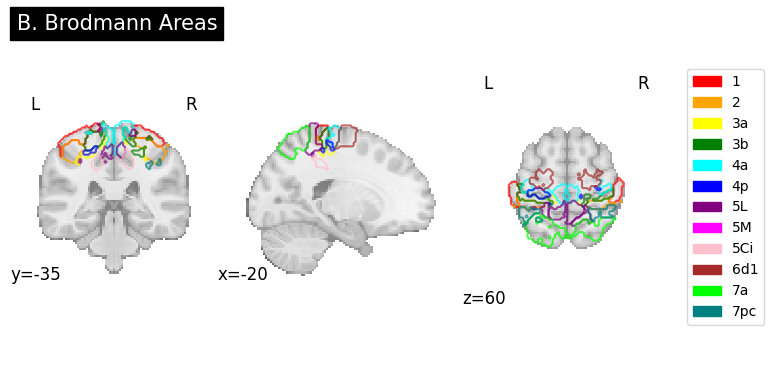

In [7]:
# Cortical masks list 
mask_list = [
    mask1_resampled,      # BA 1
    mask2_resampled,      # BA 2
    mask3a_resampled,     # BA 3a
    mask3b_resampled,     # BA 3b
    mask4a_resampled,     # BA 4a
    mask4p_resampled,     # BA 4p
    mask5l_resampled,     # BA 5L
    mask5m_resampled,     # BA 5M
    mask5ci_resampled,    # BA 5Ci
    mask6d1_resampled,    # BA 6d1
    mask7a_resampled,     # BA 7a
    mask7pc_resampled     # BA 7pc
]

# Distinct Colors
colors = [
    'red',       # 1
    'orange',    # 2
    'yellow',    # 3a
    'green',     # 3b
    'cyan',      # 4a
    'blue',      # 4p
    'purple',    # 5L
    'magenta',   # 5M
    'pink',      # 5Ci
    'brown',     # 6d1
    'lime',      # 7a
    'teal'       # 7pc
]
cmap = ListedColormap(colors)

labels = ['1', '2', '3a', '3b', '4a', '4p', '5L', '5M', '5Ci', '6d1', '7a', '7pc']


# Assign integer labels
combined_data = np.zeros(mask_list[0].shape)
for idx, mask in enumerate(mask_list, 1):
    combined_data[mask.get_fdata() > 0] = idx  # set voxels to label idx

# Save as a Nifti image
combined_mask_img = nib.Nifti1Image(combined_data, affine=mask_list[0].affine)


display_roi = plot_roi(
    combined_mask_img,
    view_type="contours",
    cut_coords=(-20, -35, 60),
    draw_cross=False,
    linewidths=1.5,
    title="B. Brodmann Areas",
    cmap=cmap 
)

# Add legend with matching colors
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]

plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('brodmann_areas.png', dpi=600, bbox_inches='tight')

plt.show()

### Plot Results

In [8]:
def combine_corrected_maps(hc_img, pat_img):
    """
    Combine thresholded HC and PAT maps into a single labeled image.

    Parameters
    ----------
    hc_img : Nifti1Image
        Corrected statistical map for the HC group.
    pat_img : Nifti1Image
        Corrected statistical map for the PAT group.

    Returns
    -------
    combined_img : Nifti1Image
        Labeled image where 1 = HC only, 2 = PAT only, and 3 = Overlap.
    """

    # Threshold data
    hc_data = 1 - hc_img.get_fdata()
    pat_data = 1 - pat_img.get_fdata()
    hc_mask = (hc_data <= 0.05).astype(np.int8)
    pat_mask = (pat_data <= 0.05).astype(np.int8)

    # Create label map: 1 = HC only, 2 = PAT only, 3 = Overlap
    combined = np.zeros(hc_mask.shape, dtype=np.int8)
    
    # Overlap first
    overlap = (hc_mask == 1) & (pat_mask == 1)
    combined[overlap] = 3

    # Exclusive regions
    combined[(hc_mask == 1) & ~overlap] = 1  # HC only
    combined[(pat_mask == 1) & ~overlap] = 2  # PAT only

    # Convert to float32 for compatibility
    combined = combined.astype(np.float32)

    # Create NIfTI
    combined_img = nib.Nifti1Image(combined, affine=hc_img.affine)

    return combined_img

In [9]:
combined_img_Seg_Ran = combine_corrected_maps(nib.load(N41HC_Seg80minusRan80_path), nib.load(N45_Seg80minusRan80_path))
combined_img_Seg_Sim = combine_corrected_maps(nib.load(N41HC_Seg80minusSim80_path), nib.load(N45_Seg80minusSim80_path))

In [10]:
def statistical_overlay_combined(combined_img, title, save_path=None):
    """
    Show statistical overlays with both ortho and mosaic views in one figure.
    
    Parameters
    ----------
    combined_img : Nifti1Image
        The combined statistical map
    title : str
        Title for the plot
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    """
    cmap = ListedColormap(["blue", "red", "yellow"])  # HC, PAT, Overlap, purple
    
    # Figure with custom height ratios
    fig = plt.figure(figsize=(15, 14))
    
    # GridSpec to control subplot sizes
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.5], hspace=-0.1,
                          top=0.95, bottom=0.05)
    
    # First row: Ortho view
    ax1 = fig.add_subplot(gs[0])
    display_ortho = plot_stat_map(
        combined_img,
        display_mode='ortho',
        colorbar=False,
        cmap=cmap,
        threshold=0,
        draw_cross=False,
        vmin=1, vmax=3,
        #title=f"{title}",
        axes=ax1
    )

    ## Cosmetics
    # Get the underlying Matplotlib Axes from any of the display panels
    first_ax = list(display_ortho.axes.values())[0].ax
    
    # Adjust title
    first_ax.set_title(
        f"{title}",
        fontsize=24,                    
        color="white",
        backgroundcolor="black",
        fontweight="normal",            
        #fontname="DejaVu Sans", 
        fontfamily="sans-serif",
        pad=25,
        bbox=dict(facecolor="black", edgecolor="none", boxstyle="square,pad=0.3")
    )

    # Increase R/L and coordinate label font sizes
    for cut_ax in display_ortho.axes.values():
        for text in cut_ax.ax.texts:
            text.set_fontsize(16)
    
        
    # Second row: Mosaic view 
    ax2 = fig.add_subplot(gs[1])
    display_mosaic = plot_stat_map(
        combined_img,
        display_mode='mosaic',
        colorbar=False,
        cmap=cmap,
        threshold=0,
        vmin=1, vmax=3,
        axes=ax2
    )
    
    for cut_ax in display_mosaic.axes.values():
        for text in cut_ax.ax.texts:
            text.set_fontsize(16)
            
    # Add single legend for the entire figure
    legend_handles = [
        mpatches.Patch(color='blue', label='HC'),
        mpatches.Patch(color='red', label='CLBP'),
        mpatches.Patch(color='yellow', label='Overlap')
    ]
    
    # Place legend at the top right of the figure
    fig.legend(handles=legend_handles, loc='upper right', 
               bbox_to_anchor=(0.98, 0.9), frameon=True, fontsize=12)
    
    # Save figure with 600 DPI if path is provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    
    return display_ortho, display_mosaic

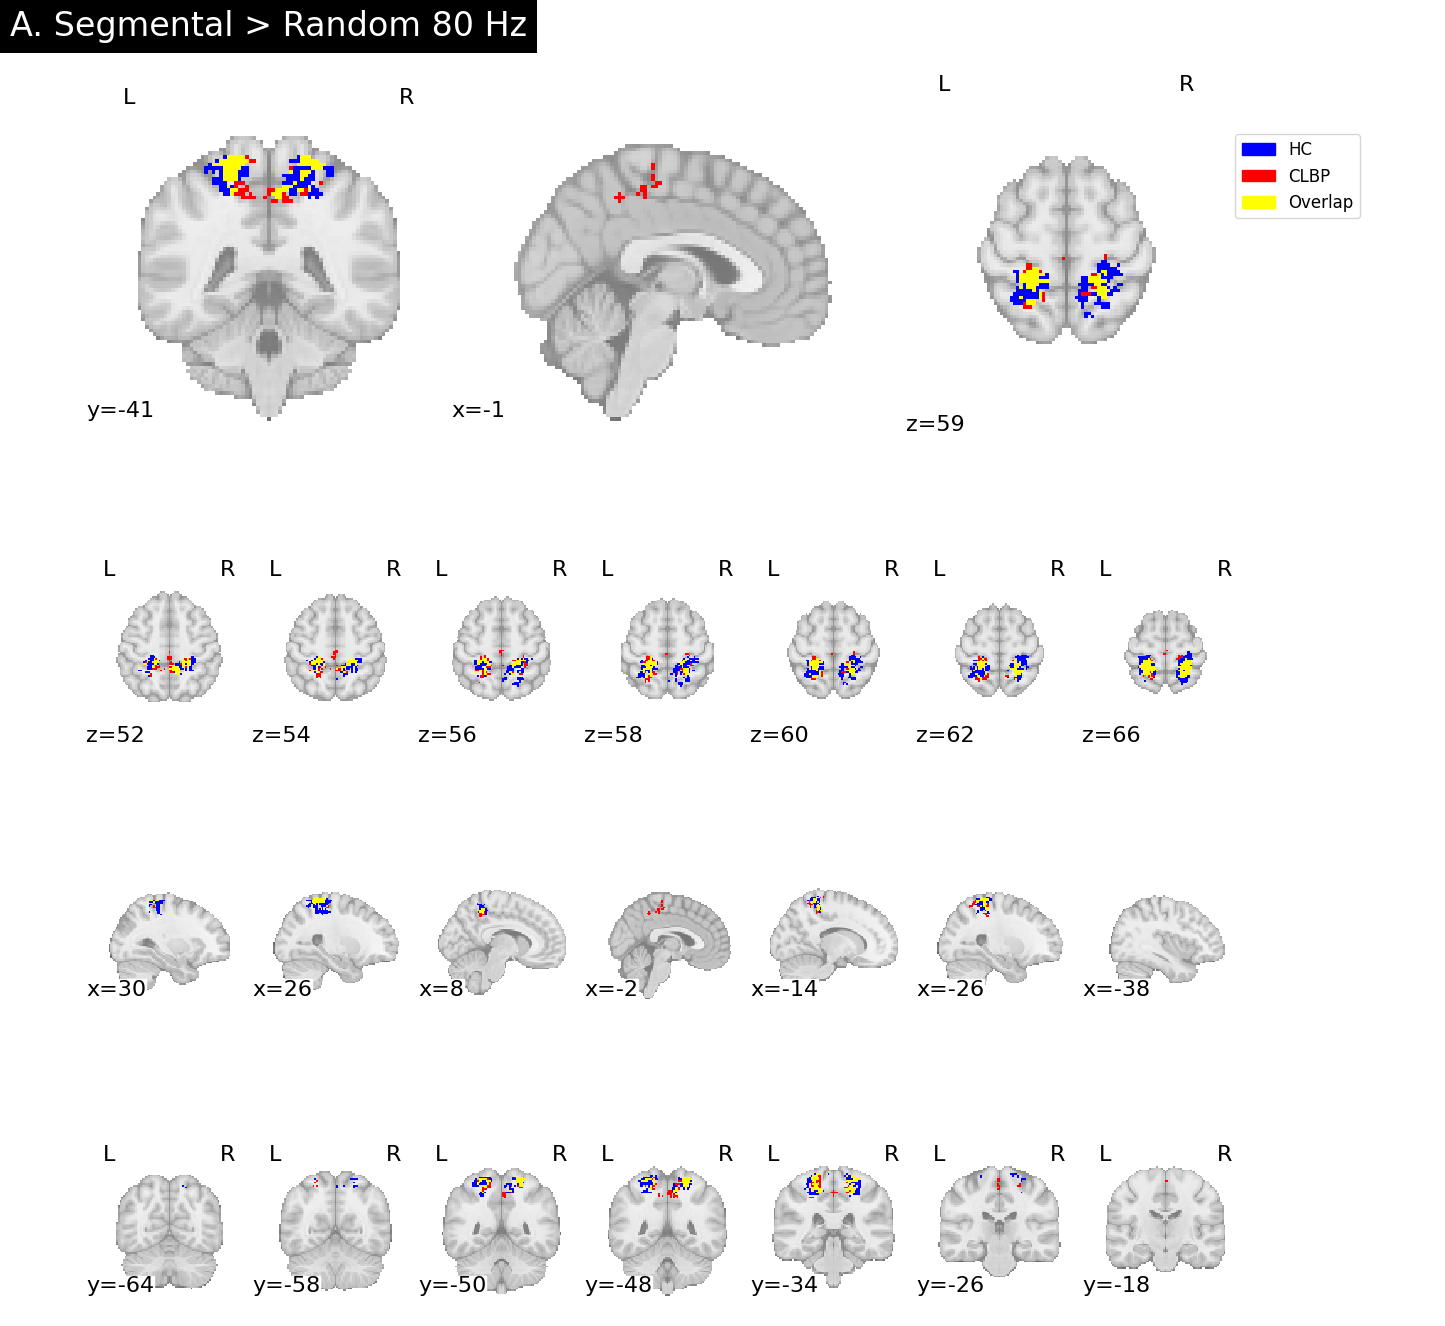

In [11]:
# Create combined plot and save

display_ortho, display_mosaic = statistical_overlay_combined(
    combined_img_Seg_Ran,
    title='A. Segmental > Random 80 Hz',
    save_path='segmental_random_80.png'
)

plt.show()

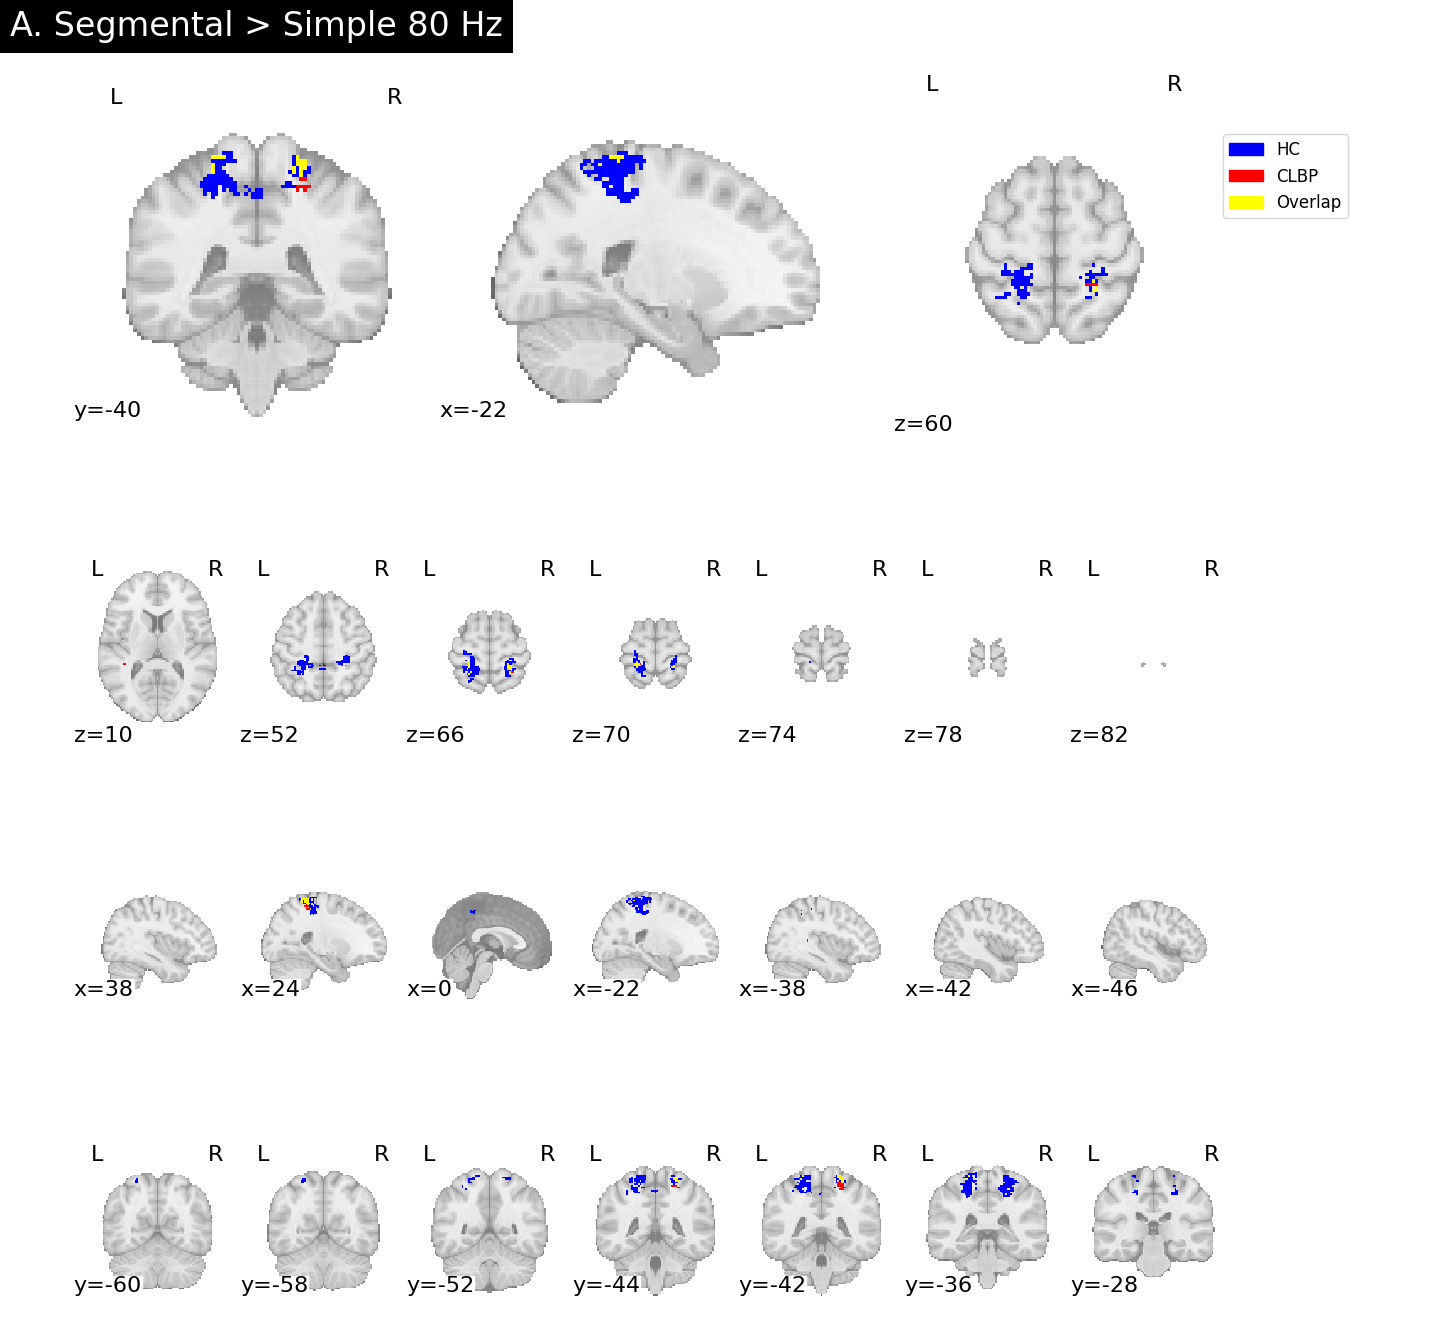

In [12]:
display_ortho, display_mosaic = statistical_overlay_combined(
    combined_img_Seg_Sim,
    title='A. Segmental > Simple 80 Hz',
    save_path='segmental_simple_80.png'
)

plt.show()

### Revision

In [13]:
from nilearn import image, datasets
import numpy as np


# Load atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata()
labels = atlas.labels

roi_names = ["Precentral Gyrus", "Postcentral Gyrus", "Superior Parietal Lobule"]
roi_indices = [labels.index(name) for name in roi_names]

roi_colors = ["cyan", "lime", "magenta"]

# Create ROI images
roi_imgs = []
for roi_idx in roi_indices:
    roi_mask = (atlas_data == roi_idx).astype(int)
    roi_img = image.new_img_like(atlas_img, roi_mask)
    roi_imgs.append(roi_img)


[get_dataset_dir] Dataset found in /home/jovyan/nilearn_data/fsl

/tmp/ipykernel_42213/3845761137.py:20: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  roi_img = image.new_img_like(atlas_img, roi_mask)


In [14]:
import matplotlib.pyplot as plt
from nilearn import image, datasets
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from nilearn.plotting import plot_stat_map


# This is the same robust function from before
def plot_filmstrip_view(
    stat_img,
    title,
    ortho_coords=(-20, -35, 60),
    x_cuts=None,
    y_cuts=None,
    z_cuts=None,
    save_path=None,
    cmap=ListedColormap(["blue", "red", "yellow"]),
    vmin=1,
    vmax=3,
    roi_imgs=None,
    roi_colors=None,

):
    """
    Creates a clean, publication-ready figure with an ortho view on top and
    optional "filmstrip" views for each orientation below.
    """
    # --- 1. Design the Grid Layout ---
    # Determine which columns we need to draw based on provided cuts
    all_cuts = [x_cuts, y_cuts, z_cuts]
    display_modes = ['x', 'y', 'z']
    ortho_titles = ["Sagittal", "Coronal", "Axial"]

    # If no filmstrips, just make a 1x3 ortho plot
    if not any(all_cuts):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for i in range(3):
            display = plot_stat_map(stat_img, display_mode=display_modes[i], cut_coords=[ortho_coords[i]],
                          axes=axes[i], colorbar=False, cmap=cmap, threshold=0.01, vmin=vmin, vmax=vmax)
            if roi_imgs is not None:
                for roi_img, color in zip(roi_imgs, roi_colors):
                    display.add_contours(
                    roi_img,
                    levels=[0.5],
                    colors=color,
                    linewidths=1
                    )
            axes[i].set_title(ortho_titles[i])
    else:
        # Determine max number of rows needed for the filmstrips
        n_filmstrip_rows = max(len(cuts) if cuts else 0 for cuts in all_cuts)
        total_rows = 1 + n_filmstrip_rows
        
        fig = plt.figure(figsize=(12, 3.5 * total_rows))
        gs = gridspec.GridSpec(total_rows, 3, figure=fig, hspace=0.3, wspace=0.1)

        # --- 2. Plot the main Ortho View in the top row ---
        for i in range(3):
            ax = fig.add_subplot(gs[0, i])
            display = plot_stat_map(stat_img, display_mode=display_modes[i], cut_coords=[ortho_coords[i]],
                          axes=ax, colorbar=False, cmap=cmap, threshold=0.01, vmin=vmin, vmax=vmax)
            if roi_imgs is not None:
                for roi_img, color in zip(roi_imgs, roi_colors):
                    display.add_contours(
                    roi_img,
                    levels=[0.5],
                    colors=color,
                    linewidths=1
                    )
            ax.set_title(ortho_titles[i], fontsize=13, weight='bold')

        # --- 3. Plot the "Filmstrip" views in the columns below ---
        for col_idx, cuts in enumerate(all_cuts):
            if cuts is None: continue
            for row_idx, cut_coord in enumerate(cuts):
                ax = fig.add_subplot(gs[row_idx + 1, col_idx])
                display = plot_stat_map(stat_img, display_mode=display_modes[col_idx], cut_coords=[cut_coord],
                              axes=ax, colorbar=False, cmap=cmap, threshold=0.01, vmin=vmin, vmax=vmax, annotate=True)

                if roi_imgs is not None:
                    for roi_img, color in zip(roi_imgs, roi_colors):
                        display.add_contours(
                        roi_img,
                        levels=[0.5],
                        colors=color,
                        linewidths=1
                        )

    # --- 4. Add overall title and legend ---
    fig.suptitle(title, fontsize=15, y=1.0, fontweight='bold')
    
    stat_handles = [
        mpatches.Patch(color='blue', label='HC'),
        mpatches.Patch(color='red', label='CLBP'),
        mpatches.Patch(color='yellow', label='Overlap')
    ]

    # ROI contour categories
    roi_handles = [
        mpatches.Patch(facecolor='none', edgecolor=color, linewidth=1.5, label=name)
        for name, color in zip(roi_names, roi_colors)
    ]

    # Combine
    legend_handles = stat_handles + roi_handles
    
    # --- Place legend above subplots ---
    fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.85, 0.98),  
        ncol=2,                      # 2 columns
        frameon=True,
        fontsize=11,
        columnspacing=1.8,
        handletextpad=0.8
    )

    # --- 5. Save the figure ---
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    return fig

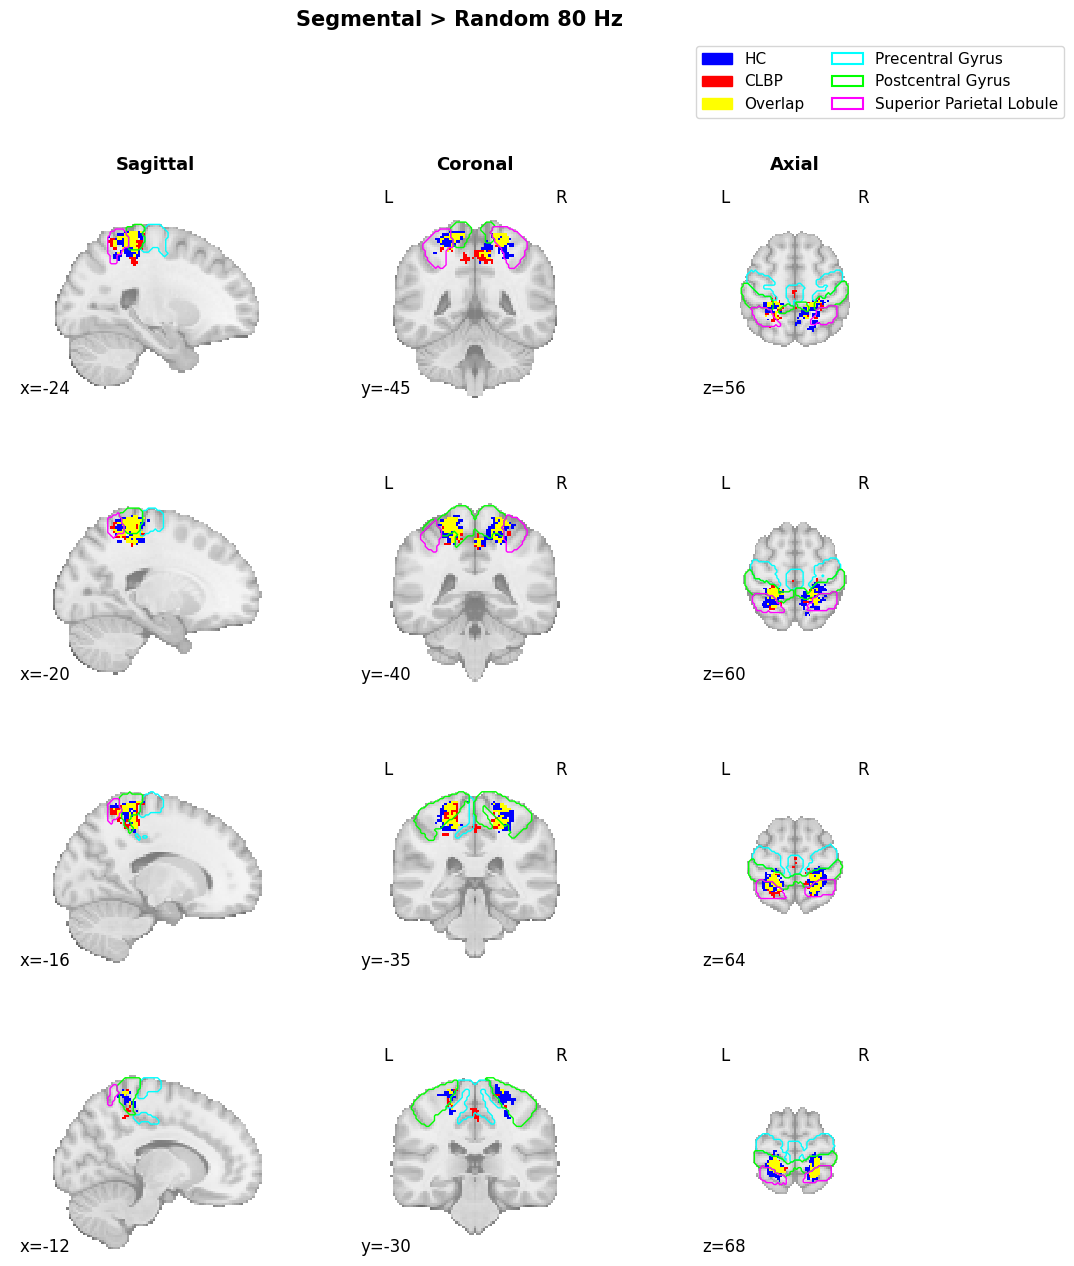

In [15]:
# Coordinates for the main ortho view
main_ortho_coords = (-24, -45, 56)

# List of cuts for all 3 orientations
sagittal_cuts = [-20, -16, -12]
coronal_cuts = [-40, -35, -30]
axial_cuts = [60, 64, 68]

# Call the function
fig = plot_filmstrip_view(
    stat_img=combined_img_Seg_Ran, 
    title='Segmental > Random 80 Hz',
    ortho_coords=main_ortho_coords,
    x_cuts=sagittal_cuts,  # X cuts
    y_cuts=coronal_cuts,  # Y cuts
    z_cuts=axial_cuts,    # Z cuts
    save_path="figure3_3_columns.tiff",
    roi_imgs=roi_imgs,
    roi_colors=roi_colors
)

plt.show()

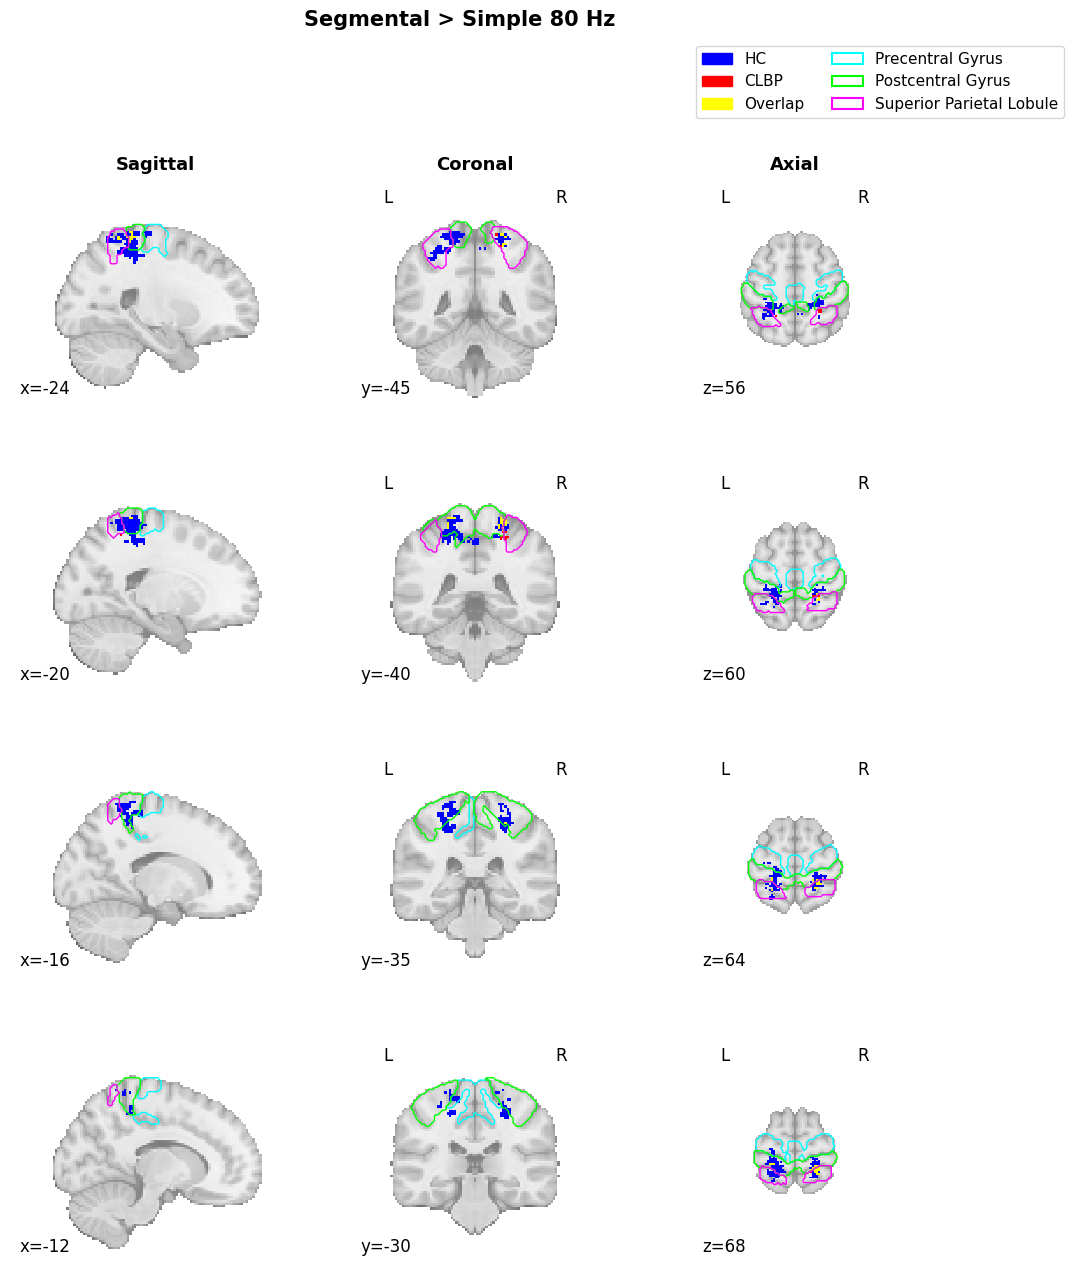

In [16]:
fig = plot_filmstrip_view(
    stat_img=combined_img_Seg_Sim, 
    title='Segmental > Simple 80 Hz',
    ortho_coords=main_ortho_coords,
    x_cuts=sagittal_cuts,  # X cuts
    y_cuts=coronal_cuts,  # Y cuts
    z_cuts=axial_cuts,    # Z cuts
    save_path="figure4_3_columns.tiff",
    roi_imgs=roi_imgs,
    roi_colors=roi_colors
)

plt.show()

In [17]:
%load_ext watermark

%watermark
%watermark --iversions

Last updated: 2026-03-02T21:35:11.109691+00:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.7.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-164-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit

logging   : 0.5.1.2
matplotlib: 3.10.8
nibabel   : 5.3.2
nilearn   : 0.11.1
numpy     : 2.2.4
siibra    : 1.0.1a11

